<p align="center">
  <img src="https://www.portafolio.co/files/article_new_multimedia/uploads/2023/10/12/652828e536642.jpeg" style="width:100%; max-width:900px; height:180px; object-fit:cover; border-radius:10px;"/>
</p>
<div style="text-align:center;">
  <h1 style="color:#FFD700; display:inline-block; margin:0;">Optimización del Transporte en Nueva York</h1>
  <p>
    <b>Green Taxi | Machine Learning & Data Science | CRISP-DM</b><br>
    <span style="font-size:1.1em;">Análisis y predicción de tarifas y duración de viajes usando datos reales de taxis verdes de NYC.</span>
  </p>
</div>

# Fase 4: Modelado (CRISP-DM)

## Propósito de la Fase de Modelado

En esta cuarta fase del proceso CRISP-DM, aplicamos técnicas de Machine Learning para construir modelos predictivos que resuelvan nuestros objetivos de negocio. Este notebook implementa un enfoque de **modelado dual** para predecir tanto el monto total de la tarifa como la duración del viaje en taxis verdes de NYC.


## 4.1 Configuración del Entorno de Modelado

Esta celda inicializa el entorno de trabajo, importando todas las librerías necesarias para la fase de modelado. Incluye herramientas para manipulación de datos, un amplio espectro de algoritmos de machine learning para regresión, y métricas de evaluación.

Componentes principales a verificar:
1.  Librerías de manipulación de datos (pandas, numpy).
2.  Algoritmos de regresión (LinearRegression, RandomForest, etc.).
3.  Herramientas de preprocesamiento y evaluación de Scikit-learn.
4.  Librerías de visualización (matplotlib, seaborn).

In [88]:
# Verifica si las librerías necesarias ya están instaladas
try:
    # Ignorar warnings
    import warnings
    warnings.filterwarnings('ignore')

    # Librerías del sistema
    import sys, subprocess

    # Importaciones base para Fase 4: Modelado
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Algoritmos de Machine Learning para Regresión
    from sklearn.linear_model import LinearRegression, Ridge, Lasso
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.neural_network import MLPRegressor
    
    # Herramientas de preprocesamiento para Modelado
    from sklearn.impute import SimpleImputer
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error)
    
    # Barra de progreso para entrenamiento de modelos
    from tqdm import tqdm
    
    # Establece el tema global
    sns.set_theme(
    style="whitegrid",                  # El estilo del gráfico (fondo y cuadrícula)
        palette="colorblind",           # La paleta de colores
        font="sans-serif",               # La familia de la fuente
        font_scale=0.9,                  # Escala de la fuente
        rc={"axes.titlesize": 14, "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10}
    )
    
    print("Dependencias ya instaladas.")

except ImportError:

    print("Dependencias no encontradas. Instalando ahora...")
    
    # Se ejecutan los comandos de instalación para Fase 4: Modelado
    %pip install --quiet matplotlib
    %pip install --quiet seaborn
    %pip install --quiet scikit-learn
    
    print("Instalación completada.")

Dependencias ya instaladas.


## 4.2 Configuración de Motores de Datos

### Instalación de Motores Parquet

Esta celda implementa una estrategia robusta para asegurar que los motores de lectura de archivos Parquet estén disponibles:

**PyArrow**: Motor principal, optimizado para rendimiento y compatibilidad
**FastParquet**: Motor alternativo, útil como respaldo

### Técnica Implementada:
- **Función Lambda Condicional**: Verifica importación antes de instalar
- **Actualización de Pip**: Asegura versión más reciente del gestor de paquetes
- **Instalación Silenciosa**: Usa `-q` para mantener salida limpia

### Importancia en el Proyecto:
Los archivos Parquet son el formato estándar para nuestros datos preprocessados debido a:
- **Eficiencia**: Compresión columnar que reduce tamaño de archivos
- **Velocidad**: Lectura más rápida que CSV para datasets grandes
- **Tipos de Datos**: Preserva tipos de datos originales sin conversiones

In [89]:
# Función lambda para verificar e instalar
instalar = lambda p: subprocess.call([sys.executable, "-c", f"import {p}"]) and subprocess.call([sys.executable, "-m", "pip", "install", p, "-q"])

# Actualizar pip
subprocess.call([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "-q"])

# Verificar e instalar condicionalmente
if instalar("pyarrow") == 0: print("PyArrow instalado/verificado")
if instalar("fastparquet") == 0: print("FastParquet instalado/verificado")

print("Listo para usar")

PyArrow instalado/verificado
FastParquet instalado/verificado
Listo para usar


## 4.3 Carga de Datos para Modelado de Monto Total

### Carga del Dataset Preprocessado (Total Amount)

Esta celda carga el primer dataset que será utilizado para predecir el **monto total de la tarifa** (`total_amount`). El archivo proviene directamente de la fase de preparación de datos.

### Características del Dataset:
**Archivo**: `preparation_total_green_tripdata_2025-06.parquet`
**Contenido**: Datos de taxis verdes preprocessados y listos para modelado
**Variables**: Incluye features ingeniería y target `total_amount`
**Estado**: Datos limpios, sin outliers extremos, con imputación aplicada

### Consideraciones Técnicas:
- **Motor PyArrow**: Utilizado para máxima compatibilidad y velocidad
- **Preservación de Tipos**: Los tipos de datos se mantienen desde la preparación
- **Memoria Eficiente**: Formato columnar optimiza el uso de RAM

Este dataset representa nuestro primer objetivo de predicción en el enfoque de modelado dual.

In [90]:
# Configuración del dataset desde el directorio local
parquet_file = "preparation_total_green_tripdata_2025-06.parquet"
# Cargar el dataset de modelado
df_modeling_total = pd.read_parquet(parquet_file, engine="pyarrow")

print("Dataset Cargado.")

Dataset Cargado.


## 4.4 Inspección de la Estructura del Dataset

### Información que Obtendremos:
**Dimensiones**: Número de filas y columnas del dataset

**Tipos de Datos**: Distribución de tipos (numéricos, categóricos, fechas)

**Memoria**: Uso de memoria total del dataset

**Valores Nulos**: Identificación de missingness residual

**Índice**: Estructura del índice del DataFrame

### Importancia para el Modelado:
- **Validación**: Confirma que el preprocessing fue exitoso
- **Selección de Features**: Identifica variables numéricas disponibles
- **Optimización**: Informa sobre el uso de memoria
- **Control de Calidad**: Verifica ausencia de problemas de datos

Esta inspección es crucial antes de proceder con la definición de variables y división de datos.

In [91]:
df_modeling_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49390 entries, 0 to 49389
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   pickup_day              49390 non-null  float64
 1   pickup_day_of_week      49390 non-null  float64
 2   pickup_is_weekend       49390 non-null  int64  
 3   pickup_hour             49390 non-null  float64
 4   pickup_time_of_day_Ord  49390 non-null  float64
 5   is_peak_hour            49390 non-null  int64  
 6   VendorID                49390 non-null  float64
 7   RatecodeID              49390 non-null  float64
 8   PULocationID            49390 non-null  float64
 9   payment_type            49390 non-null  float64
 10  store_and_fwd_flag_0    49390 non-null  int64  
 11  store_and_fwd_flag_1    49390 non-null  int64  
 12  trip_type_0             49390 non-null  int64  
 13  trip_type_1             49390 non-null  int64  
 14  passenger_count         49390 non-null  flo

### Interpretación de la Información del Dataset

La salida del `.info()` nos permite evaluar:

**Calidad de Datos**: Verificar que no existan valores nulos inesperados

**Preparación Exitosa**: Confirmar que todas las transformaciones se aplicaron correctamente

**Compatibilidad**: Asegurar que los tipos de datos son apropiados para ML

**Eficiencia**: Evaluar el uso de memoria para datasets grandes

Esta información guía las decisiones sobre qué variables usar como features en nuestros modelos de regresión.

## 4.5 Definición de Variables para Predicción de total_amount

### Configuración del Problema de Regresión

### Variables Definidas:
**Variable Objetivo (Target)**: `total_amount` - El monto total de la tarifa que queremos predecir

**Variables Explicativas (Features)**: Todas las variables numéricas excepto el target

**Exclusiones**: Solo se excluye la variable objetivo para evitar data leakage

### Metodología de Selección de Features:
1. **Filtrado por Tipo**: `select_dtypes(include=np.number)` selecciona solo variables numéricas
2. **Exclusión del Target**: Evita que el modelo aprenda a predecir usando la respuesta
3. **Separación X/y**: Divide claramente entre predictores y variable respuesta


In [92]:
# Objetivo
target_variable = 'total_amount'
# Exclusión de variables
exclude_cols = [target_variable] 
features = [col for col in df_modeling_total.select_dtypes(include=np.number).columns if col not in exclude_cols]
# División de datos
X = df_modeling_total[features]
y = df_modeling_total[target_variable]

print(f"Características seleccionadas para el modelado.")

Características seleccionadas para el modelado.


## 4.6 División de Datos en Entrenamiento y Prueba

### Parámetros de División:
**Proporción**: 70% entrenamiento / 30% prueba

**Random State**: 42 (para reproducibilidad)

**Estratificación**: No aplicada (variable continua)

### Distribución Resultante:
- **Entrenamiento (70%)**: Datos para entrenar los modelos
- **Prueba (30%)**: Datos para evaluación final e imparcial

### Justificación de la Proporción:
- **70/30**: Proporción clásica que equilibra:
  - Suficientes datos para entrenamiento robusto
  - Conjunto de prueba representativo para evaluación confiable
- **Random State 42**: Asegura que todos los modelos usen la misma división
- **Reproducibilidad**: Permite replicar exactamente los mismos resultados

Esta división es crucial para obtener estimaciones no sesgadas del rendimiento del modelo en datos no vistos.

In [93]:
# División de datos en entrenamiento y prueba (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Datos divididos en conjuntos de entrenamiento y prueba.")

Datos divididos en conjuntos de entrenamiento y prueba.


## 4.7 Definición del Arsenal de Algoritmos de Machine Learning

### Configuración del Diccionario de Modelos

Esta celda define nuestro conjunto diverso de algoritmos de regresión, representando diferentes familias de Machine Learning:

### Familia de Algoritmos Seleccionados:

**1. Algoritmos Lineales:**
- **LinearRegression**: Baseline lineal sin regularización
- **Ridge**: Regresión lineal con regularización L2
- **Lasso**: Regresión lineal con regularización L1 y selección de features

**2. Algoritmos Basados en Árboles:**
- **DecisionTree**: Modelo interpretable basado en reglas
- **RandomForest**: Ensemble de árboles, reduce overfitting

**3. Algoritmos Basados en Instancias:**
- **KNeighbors**: Predicción basada en vecinos más cercanos (k=5)

**4. Algoritmos de Redes Neuronales:**
- **MLPRegressor**: Red neuronal multicapa (100 neuronas, 500 iteraciones)

### Configuraciones de Hiperparámetros:
- **Random State 42**: Reproducibilidad en algoritmos estocásticos
- **n_jobs=-1**: Paralelización para aprovechar todos los cores
- **Configuraciones Conservadoras**: Parámetros que evitan overfitting excesivo

In [94]:
# Crear instancias de los modelos
# Linear
lr = LinearRegression()
#pf = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression()) 
# Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
dt = DecisionTreeRegressor(random_state=42)
# Knn
knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1) # k=5 es un punto de partida común
ridge = Ridge(random_state=42)
lasso = Lasso(random_state=42)
# otros
#xgboost = GradientBoostingRegressor(random_state=42)
#svr = SVR(kernel='rbf', C=1.0)
neural_network = MLPRegressor(hidden_layer_sizes=(100,), random_state=42, max_iter=500)

# Definicion del diccionario de los modelos.
models_regression = {
    'LinearRegression': lr,
    #'PolynomialFeatures_LR': pf, 
    'RandomForest': rf,
    'DecisionTree': dt,
    'KNeighbors': knn,
    'Ridge': ridge,
    'Lasso': lasso,
    #'XGBoost': xgboost,
    #'SVR': svr,
    'NeuralNetwork': neural_network
}

print("Diccionario de modelos creado.")

Diccionario de modelos creado.


## 4.8 Entrenamiento y Evaluación Sistemática de Modelos

### Ciclo de Entrenamiento Automatizado

Esta celda implementa un pipeline automatizado que entrena y evalúa todos los modelos de manera sistemática:

### Componentes del Pipeline:

**1. Manejo de Valores Faltantes:**
- **SimpleImputer con estrategia 'median'**: Robusta a outliers
- **Fit en entrenamiento**: Evita data leakage
- **Transform en prueba**: Mantiene consistencia

**2. Métricas de Evaluación:**
- **MAE (Mean Absolute Error)**: Error promedio en unidades originales
- **MSE (Mean Squared Error)**: Penaliza errores grandes cuadráticamente
- **RMSE (Root Mean Squared Error)**: Error en unidades originales, sensible a outliers
- **R² (Coefficient of Determination)**: Proporción de varianza explicada

**3. Proceso Automatizado:**
- **Iteración**: Cada modelo se entrena y evalúa automáticamente
- **Almacenamiento**: Resultados organizados en diccionario estructurado
- **Monitoreo**: Progreso reportado por modelo completado

### Importancia Metodológica:
Este enfoque asegura comparaciones justas entre algoritmos bajo condiciones idénticas.

In [95]:
# Manejo de valores faltantes
# !!! Error de no tratamiento de valores faltantes ¡¡¡
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
# !!! Error de no tratamiento de valores faltantes ¡¡¡

In [96]:
# Entrenamiento y evaluación sistemática de modelos
print(f"Iniciando entrenamiento de {len(models_regression)} modelos de regresión para TOTAL AMOUNT...")
print("=" * 80)

# Diccionario para almacenar resultados de métricas
test_metrics_results = {}
results_table = []

# Ciclo de entrenamiento y evaluación de modelos con barra de progreso
print("Procesando modelos...")
for idx, (name, model) in enumerate(tqdm(models_regression.items(), desc="Entrenando modelos", ncols=100), 1):
    # Entrenar el modelo
    model.fit(X_train_imputed, y_train)
    
    # Realizar predicciones en conjunto de prueba
    y_pred_test = model.predict(X_test_imputed)

    # Calcular métricas de evaluación
    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_test)

    # Almacenar resultados
    test_metrics_results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    }
    
    # Guardar datos para tabla final
    results_table.append({
        'idx': idx,
        'name': name,
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'mse': mse
    })

print("\n" + "=" * 80)
print("RESULTADOS DEL ENTRENAMIENTO")
print("=" * 80)

# Configuración de tabla de resultados
print(f"{'#':<3} | {'Modelo':<18} | {'R²':<8} | {'RMSE':<10} | {'MAE':<10} | {'MSE':<12} | {'Estado':<8}")
print("-" * 80)

# Mostrar todos los resultados en formato tabular
for result in results_table:
    print(f"{result['idx']:<3} | {result['name']:<18} | {result['r2']:<8.4f} | {result['rmse']:<10.4f} | {result['mae']:<10.4f} | {result['mse']:<12.4f} | {'OK':<8}")

print("-" * 80)
print(f"TOTAL AMOUNT: {len(test_metrics_results)} modelos entrenados y evaluados exitosamente.")

Iniciando entrenamiento de 7 modelos de regresión para TOTAL AMOUNT...
Procesando modelos...


Entrenando modelos: 100%|█████████████████████████████████████████████| 7/7 [00:26<00:00,  3.78s/it]


RESULTADOS DEL ENTRENAMIENTO
#   | Modelo             | R²       | RMSE       | MAE        | MSE          | Estado  
--------------------------------------------------------------------------------
1   | LinearRegression   | 0.4490   | 11.3075    | 7.5602     | 127.8595     | OK      
2   | RandomForest       | 0.8536   | 5.8286     | 2.7304     | 33.9727      | OK      
3   | DecisionTree       | 0.7326   | 7.8775     | 3.4797     | 62.0550      | OK      
4   | KNeighbors         | 0.4737   | 11.0509    | 6.9391     | 122.1214     | OK      
5   | Ridge              | 0.4486   | 11.3118    | 7.5633     | 127.9573     | OK      
6   | Lasso              | 0.2759   | 12.9626    | 9.2926     | 168.0286     | OK      
7   | NeuralNetwork      | 0.8211   | 6.4423     | 3.4542     | 41.5032      | OK      
--------------------------------------------------------------------------------
TOTAL AMOUNT: 7 modelos entrenados y evaluados exitosamente.


## 4.9 Tabla Comparativa de Métricas de Rendimiento

### Interpretación de Métricas:

**MAE (Mean Absolute Error)**:
- **Unidad**: Dólares (mismo que target)
- **Interpretación**: Error promedio absoluto en predicciones
- **Objetivo**: Minimizar

**MSE (Mean Squared Error)**:
- **Unidad**: Dólares al cuadrado
- **Interpretación**: Penaliza errores grandes más severamente
- **Objetivo**: Minimizar

**RMSE (Root Mean Squared Error)**:
- **Unidad**: Dólares (mismo que target)
- **Interpretación**: Error estándar de predicciones
- **Objetivo**: Minimizar

**R² (Coefficient of Determination)**:
- **Rango**: 0 a 1 (puede ser negativo si el modelo es muy malo)
- **Interpretación**: Proporción de varianza explicada por el modelo
- **Objetivo**: Maximizar
---

## 4.10 Dashboard Integral de Visualización de Métricas

### Estructura del Dashboard (Grid 3x2):

**Panel Superior Izquierdo - R² Score Individual:**
- **Tipo**: Gráfico de barras horizontales
- **Métrica**: Coeficiente de determinación
- **Interpretación**: "Mayor es mejor" - muestra capacidad explicativa

**Panel Superior Derecho - Comparación General de Errores:**
- **Tipo**: Gráfico de barras agrupadas
- **Métricas**: MSE, RMSE, MAE conjuntamente
- **Interpretación**: "Menor es mejor" - permite comparar escalas de error

**Panel Medio Izquierdo - MSE Individual:**
- **Tipo**: Gráfico de barras horizontales
- **Métrica**: Error cuadrático medio
- **Interpretación**: Sensible a outliers, penaliza errores grandes

**Panel Medio Derecho - RMSE Individual:**
- **Tipo**: Gráfico de barras horizontales
- **Métrica**: Raíz del error cuadrático medio
- **Interpretación**: En unidades originales, balance entre MAE y MSE

**Panel Inferior Izquierdo - MAE Individual:**
- **Tipo**: Gráfico de barras horizontales
- **Métrica**: Error absoluto medio
- **Interpretación**: Error promedio directo, robusto a outliers

**Panel Inferior Derecho - Heatmap de Rankings:**
- **Tipo**: Mapa de calor
- **Contenido**: Ranking de cada modelo por métrica
- **Interpretación**: Vista consolidada del rendimiento relativo

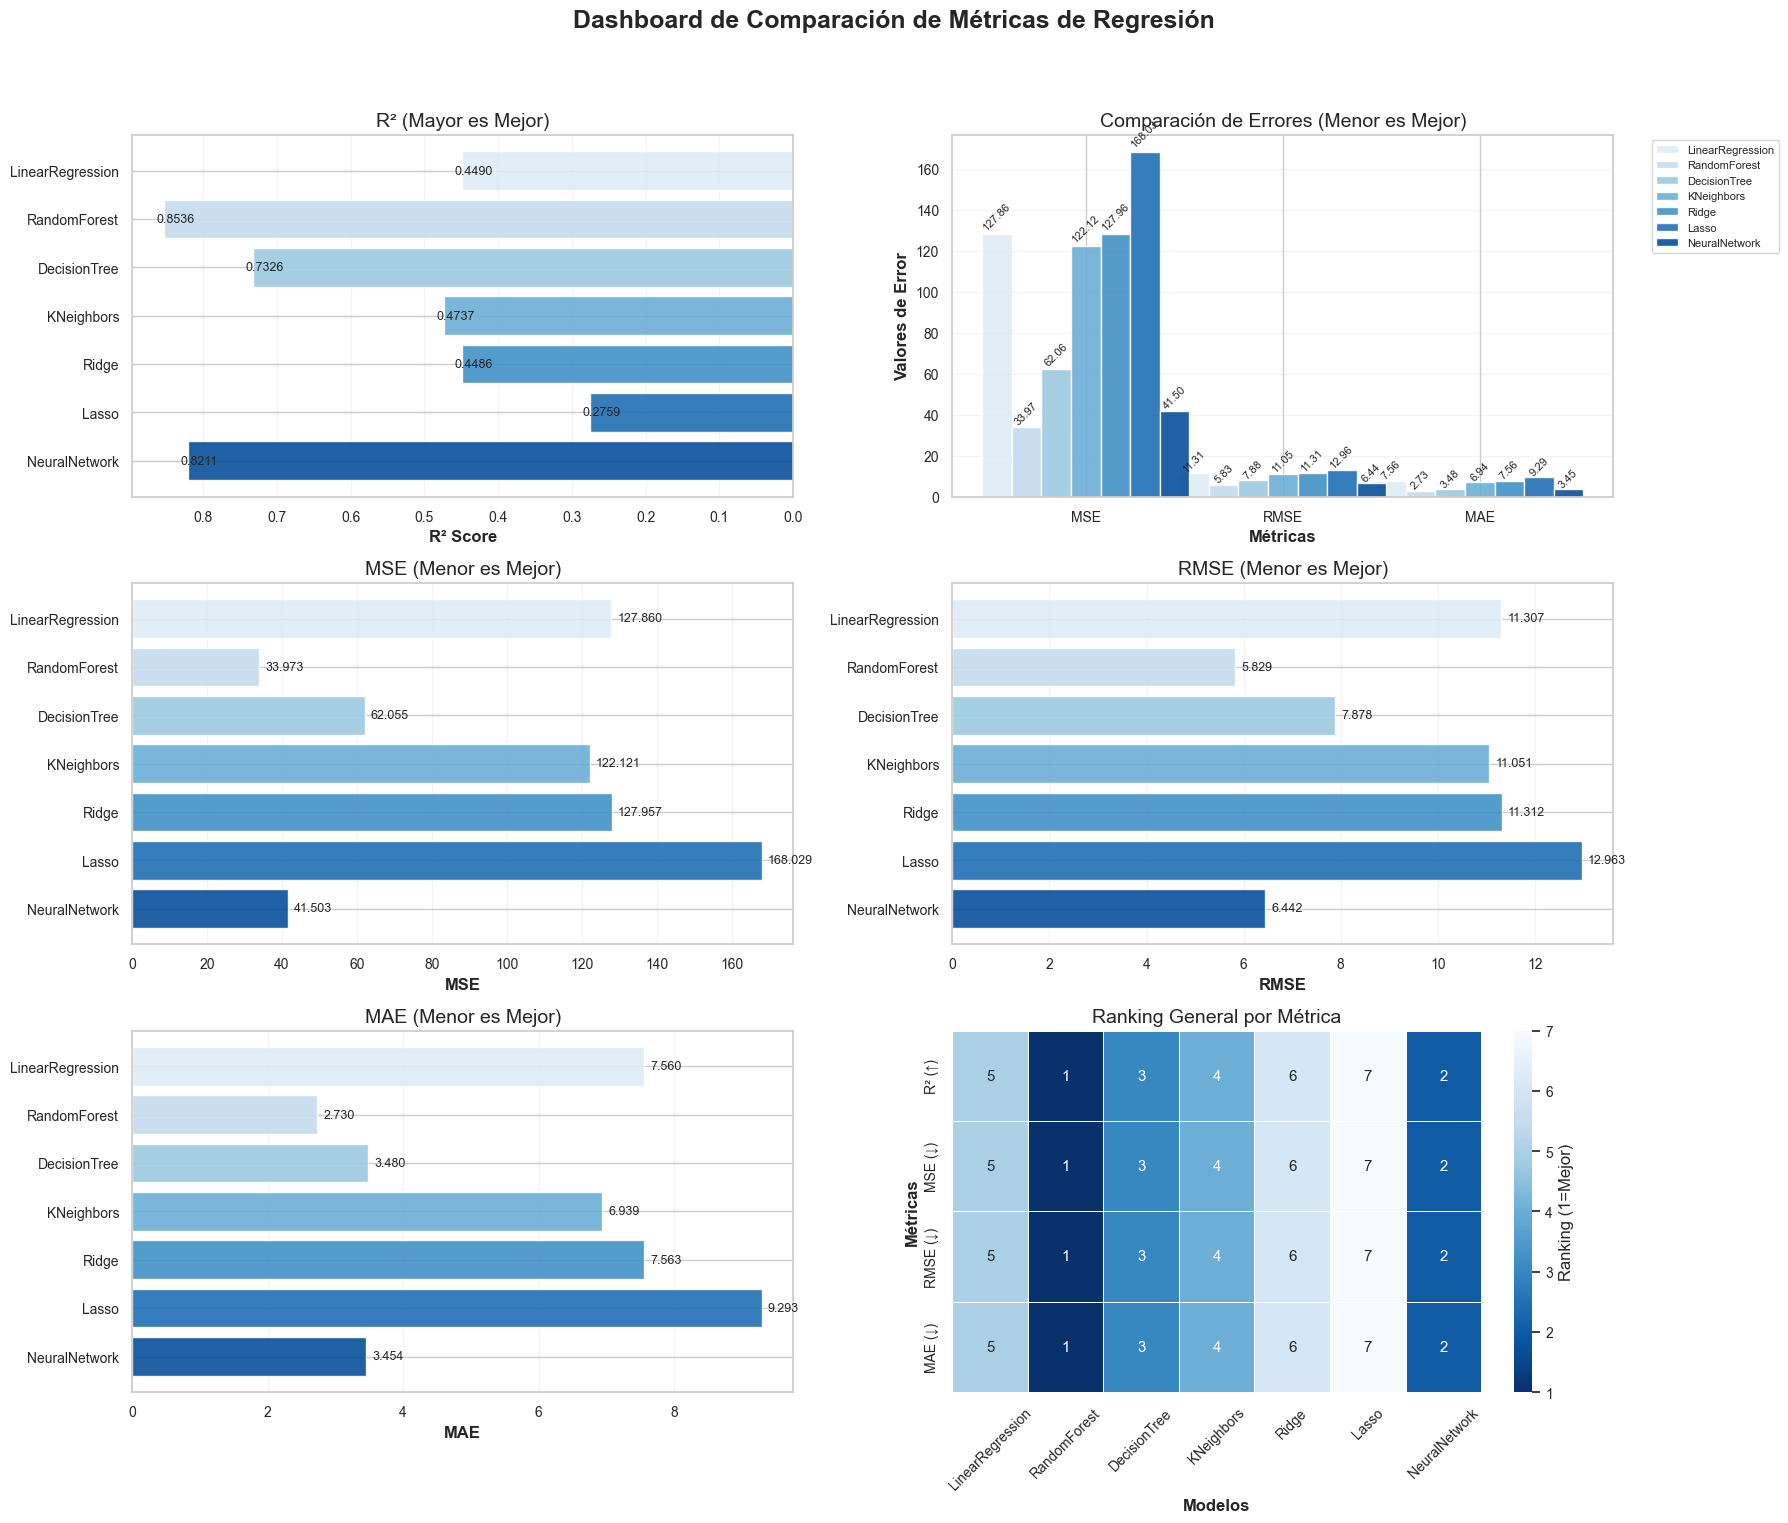

In [97]:
# --- Configuración del Dashboard ---
fig, axes = plt.subplots(3, 2, figsize=(18, 16)) # Mantenemos grid 3x2
fig.suptitle('Dashboard de Comparación de Métricas de Regresión', fontsize=18, fontweight='bold')

# Preparar datos comunes
models_names = list(test_metrics_results.keys())
colors = sns.color_palette("Blues", len(models_names))

# --- Gráfico 1 (NUEVO): R² Score (Independiente) ---
ax1 = axes[0, 0] # Posición superior izquierda
r2_scores = [test_metrics_results[name]['R²'] for name in models_names]
bars1 = ax1.barh(models_names, r2_scores, color=colors, alpha=0.9)
ax1.set_xlabel('R² Score', fontweight='bold')
ax1.set_title('R² (Mayor es Mejor)')
ax1.grid(True, alpha=0.2, axis='x')
# Etiquetas en barras horizontales
for bar, score in zip(bars1, r2_scores):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.4f}',
             ha='left', va='center', fontsize=9)
ax1.invert_xaxis() # Opcional: para que la mejor barra (más larga) esté arriba si se ordena
ax1.invert_yaxis() # Para que los nombres de modelo coincidan con otras barras H

# --- Gráfico 2 (NUEVO): Comparación General (MSE, RMSE, MAE) ---
ax2 = axes[0, 1] # Posición superior derecha
metrics_compare = ['MSE', 'RMSE', 'MAE'] # Excluimos R²
x_pos = np.arange(len(metrics_compare))
width = 0.15 # Ajusta el ancho si es necesario

for i, (name, color) in enumerate(zip(models_names, colors)):
    # Obtener solo MSE, RMSE, MAE
    values = [test_metrics_results[name][metric] for metric in metrics_compare]
    bars2 = ax2.bar(x_pos + i * width, values, width, label=name, color=color, alpha=0.9, edgecolor='white')

    # Etiquetas en barras verticales (ajustadas)
    for bar, val in zip(bars2, values):
        height = bar.get_height()
        # Ajustar posición vertical para evitar solapamientos
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.01, f'{val:.2f}', # Usar .2f para errores
                 ha='center', va='bottom', fontsize=8, rotation=45)

ax2.set_xlabel('Métricas', fontweight='bold')
ax2.set_ylabel('Valores de Error', fontweight='bold')
ax2.set_title('Comparación de Errores (Menor es Mejor)')
ax2.set_xticks(x_pos + width * (len(models_names) - 1) / 2)
ax2.set_xticklabels(metrics_compare, rotation=0)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.2, axis='y')

# --- Gráfico 3: MSE (Individual) ---
ax3 = axes[1, 0] # Posición media izquierda
mse_scores = [test_metrics_results[name]['MSE'] for name in models_names]
bars3 = ax3.barh(models_names, mse_scores, color=colors, alpha=0.9)
ax3.set_xlabel('MSE', fontweight='bold')
ax3.set_title('MSE (Menor es Mejor)')
ax3.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars3, mse_scores):
    ax3.text(bar.get_width() + max(mse_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', # Ajuste decimales
             ha='left', va='center', fontsize=9)
ax3.invert_yaxis() # Para alinear nombres

# --- Gráfico 4: RMSE (Individual) ---
ax4 = axes[1, 1] # Posición media derecha
rmse_scores = [test_metrics_results[name]['RMSE'] for name in models_names]
bars4 = ax4.barh(models_names, rmse_scores, color=colors, alpha=0.9)
ax4.set_xlabel('RMSE', fontweight='bold')
ax4.set_title('RMSE (Menor es Mejor)')
ax4.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars4, rmse_scores):
    ax4.text(bar.get_width() + max(rmse_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             ha='left', va='center', fontsize=9)
ax4.invert_yaxis() # Para alinear nombres

# --- Gráfico 5: MAE (Individual) ---
ax5 = axes[2, 0] # Posición inferior izquierda
mae_scores = [test_metrics_results[name]['MAE'] for name in models_names]
bars5 = ax5.barh(models_names, mae_scores, color=colors, alpha=0.9)
ax5.set_xlabel('MAE', fontweight='bold')
ax5.set_title('MAE (Menor es Mejor)')
ax5.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars5, mae_scores):
    ax5.text(bar.get_width() + max(mae_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             ha='left', va='center', fontsize=9)
ax5.invert_yaxis() # Para alinear nombres

# --- Gráfico 6: Ranking Heatmap (Independiente) ---
ax6 = axes[2, 1] # Posición inferior derecha
comparison_df = pd.DataFrame(test_metrics_results).T
# Usar todas las métricas originales para el ranking
metrics_all = ['R²', 'MSE', 'RMSE', 'MAE']
ranking_matrix = []
for metric in metrics_all:
    # Rankear R² descendente, errores ascendente
    ranked = comparison_df[metric].rank(ascending=(metric != 'R²'))
    ranking_matrix.append(ranked.values)

# Crear DataFrame del ranking
ranking_df = pd.DataFrame(ranking_matrix,
                          index=[f'{m} {"(↑)" if m=="R²" else "(↓)"}' for m in metrics_all],
                          columns=models_names)

sns.heatmap(ranking_df, annot=True, fmt='.0f', cmap='Blues_r', ax=ax6, # Usar Blues_r para que 1 sea oscuro
            cbar_kws={'label': 'Ranking (1=Mejor)'}, linewidths=.5)
ax6.set_title('Ranking General por Métrica')
ax6.set_xlabel('Modelos', fontweight='bold')
ax6.set_ylabel('Métricas', fontweight='bold')
# Rotar etiquetas X para evitar solapamiento
ax6.tick_params(axis='x', rotation=45)

# --- Ajuste Final ---
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar rect para dejar espacio al supertítulo
plt.show()

## 4.11 Análisis de Mejores Modelos y Ranking Promedio

### Identificación de Campeones por Métrica

Esta celda proporciona un análisis detallado que identifica el modelo óptimo para cada métrica específica:

### Metodología de Análisis:
**Campeones por Métrica Individual:**
- **Mejor MAE**: Modelo con menor error absoluto promedio
- **Mejor MSE**: Modelo con menor error cuadrático medio
- **Mejor RMSE**: Modelo con menor error estándar
- **Mejor R²**: Modelo con mayor capacidad explicativa

**Ranking Promedio:**
- **Cálculo**: Promedio de rankings individuales de cada modelo
- **Interpretación**: Menor valor indica mejor rendimiento general
- **Beneficio**: Identifica el modelo más consistente across todas las métricas

### Valor para la Toma de Decisiones:
- **Especialización**: Algunos modelos pueden destacar en métricas específicas
- **Consistencia**: El ranking promedio revela modelos balanceados
- **Trade-offs**: Permite identificar compromisos entre diferentes tipos de error
- **Selección Final**: Base cuantitativa para decisión de modelo de producción

In [98]:

# Resumen Mejorado con Ranking Promedio
print("\nResumen de los Mejores Modelos")
best_models = {}
metrics_reg = ['MAE', 'MSE', 'RMSE', 'R²']
for metric in metrics_reg:
    if metric == 'R²':
        best = max(test_metrics_results.items(), key=lambda x: x[1][metric])
    else:
        best = min(test_metrics_results.items(), key=lambda x: x[1][metric])
    print(f"Mejor {metric:>4} {'(Mayor)':<7}: {best[0]:<20} = {best[1][metric]:.4f}")
    best_models[metric] = best[0]

# Ranking Promedio
avg_ranks = ranking_df.mean().sort_values()
print("\nRanking Promedio (Menor = Mejor General):")
for model, rank in avg_ranks.items():
    print(f"{model:<20}: {rank:.2f}")


Resumen de los Mejores Modelos
Mejor  MAE (Mayor): RandomForest         = 2.7304
Mejor  MSE (Mayor): RandomForest         = 33.9727
Mejor RMSE (Mayor): RandomForest         = 5.8286
Mejor   R² (Mayor): RandomForest         = 0.8536

Ranking Promedio (Menor = Mejor General):
RandomForest        : 1.00
NeuralNetwork       : 2.00
DecisionTree        : 3.00
KNeighbors          : 4.00
LinearRegression    : 5.00
Ridge               : 6.00
Lasso               : 7.00


## 4.12 Persistencia de Datos de Modelado (Total Amount)

### Exportación de Dataset de Modelado

Esta celda guarda el dataset de modelado en formato Parquet para uso futuro:

### Características del Archivo Exportado:
**Nombre**: `modeling_total_green_tripdata_2025-06.parquet`
**Contenido**: Dataset completo usado para modelado de `total_amount`
**Formato**: Parquet para eficiencia y preservación de tipos
**Propósito**: Reproducibilidad y trazabilidad del proceso

### Beneficios de la Persistencia:
- **Reproducibilidad**: Permite recrear exactamente los mismos resultados
- **Auditoría**: Rastrea qué datos se usaron para cada modelo
- **Eficiencia**: Evita recomputar preprocessing en futuras iteraciones
- **Colaboración**: Otros investigadores pueden usar los mismos datos
- **Versionado**: Mantiene versiones específicas de datos de modelado

### Manejo de Errores:
El bloque try-except asegura que cualquier problema de escritura sea reportado claramente, facilitando la detección de problemas de permisos, espacio en disco, o corrupción de datos.

---

In [99]:
# Define el nombre del archivo
modeling = 'modeling_total_green_tripdata_2025-06.parquet'

# Guarda el DataFrame df_modeling en formato Parquet
try:
    df_modeling_total.to_parquet(modeling, index=False) 
    print(f"DataFrame guardado exitosamente como '{modeling}'")
except Exception as e:
    print(f"Error al guardar como Parquet: {e}")

DataFrame guardado exitosamente como 'modeling_total_green_tripdata_2025-06.parquet'


---

# Segundo Ciclo de Modelado: Predicción de Trip Duration Minutes

## Transición al Objetivo Secundario

Habiendo completado el modelado para predicción de `total_amount`, iniciamos ahora el segundo ciclo de nuestro enfoque de **modelado dual**. Este nuevo ciclo se enfoca en predecir la duración del viaje (`trip_duration_min`), aplicando la misma metodología rigurosa pero adaptada a un target diferente.

### Diferencias Clave con el Primer Ciclo:
- **Target Variable**: `trip_duration_min` en lugar de `total_amount`
- **Dataset**: Datos preprocessados específicamente para duración de viajes
- **Interpretación**: Resultados en minutos vs. dólares
- **Aplicaciones**: Optimización de rutas vs. estimación de costos

Esta aproximación dual nos permitirá construir un sistema integral de predicción para el transporte urbano.

---

## 4.13 Carga de Datos para Modelado de Duración de Viajes

### Carga del Dataset Preprocessado (Trip Duration)

Esta celda carga el segundo dataset, específicamente preparado para predecir la **duración de viajes** (`trip_duration_min`):

### Características del Dataset:
**Archivo**: `preparation_trip_green_tripdata_2025-06.parquet`
**Contenido**: Datos de taxis verdes preprocessados para duración de viajes
**Variables**: Incluye features relevantes y target `trip_duration_min`
**Diferencias con Total Amount**: 
- Target diferente (tiempo vs. dinero)
- Posibles features específicas para temporal modeling
- Escalas de valores diferentes

### Consideraciones Específicas para Duración:
- **Unidad del Target**: Minutos (temporal)
- **Rango de Valores**: Típicamente menor varianza que montos monetarios
- **Features Relevantes**: Variables de distancia y tráfico pueden ser más críticas
- **Outliers**: Viajes extremadamente largos o cortos requieren tratamiento especial

Este dataset representa nuestro segundo objetivo en el enfoque de modelado dual para optimización integral del transporte.

In [100]:
# Configuración del dataset desde el directorio local
parquet_file = "preparation_trip_green_tripdata_2025-06.parquet"
# Cargar el dataset de modelado
df_modeling_trip = pd.read_parquet(parquet_file, engine="pyarrow")

print("Dataset Cargado.")

Dataset Cargado.


## 4.14 Inspección de la Estructura del Dataset de Duración

### Análisis de Información del Dataset de Trip Duration

Esta celda examina la estructura específica del dataset de duración de viajes:

### Aspectos a Verificar:
**Dimensiones**: Comparar tamaño con dataset de total_amount

**Features Disponibles**: Identificar variables específicas para predicción temporal

**Tipos de Datos**: Confirmar que el preprocessing temporal fue exitoso

**Target Variable**: Verificar presencia y tipo de `trip_duration_min`

**Calidad**: Confirmar ausencia de valores nulos

### Diferencias Esperadas:
- **Posibles Features Adicionales**: Variables específicas para modelado temporal
- **Escalas Diferentes**: Duración en minutos vs. montos en dólares
- **Distribuciones**: Rangos de valores típicamente más acotados que montos

Esta inspección asegura que el dataset está correctamente preparado para el modelado de duración de viajes.

In [101]:
df_modeling_trip.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49390 entries, 0 to 49389
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   pickup_day              49390 non-null  float64
 1   pickup_day_of_week      49390 non-null  float64
 2   pickup_is_weekend       49390 non-null  int64  
 3   pickup_hour             49390 non-null  float64
 4   pickup_time_of_day_Ord  49390 non-null  float64
 5   is_peak_hour            49390 non-null  int64  
 6   PULocationID            49390 non-null  float64
 7   payment_type            49390 non-null  float64
 8   trip_type_0             49390 non-null  int64  
 9   trip_type_1             49390 non-null  int64  
 10  passenger_count         49390 non-null  float64
 11  trip_duration_min       49390 non-null  Int32  
dtypes: Int32(1), float64(7), int64(4)
memory usage: 4.8 MB


## 4.15 Definición de Variables para Predicción de Duración

### Configuración del Segundo Problema de Regresión

Esta celda establece la configuración para nuestro segundo problema de Machine Learning:

### Variables Definidas para Duración:
**Variable Objetivo (Target)**: `trip_duration_min` - La duración del viaje en minutos
**Variables Explicativas (Features)**: Todas las variables numéricas excepto el nuevo target
**Metodología Consistente**: Misma estrategia que en el primer ciclo

### Consideraciones Específicas:
**Unidad del Target**: Minutos (temporal) vs. dólares (monetario)
**Interpretación**: Tiempo de viaje vs. costo de viaje
**Aplicación**: Optimización de rutas y estimación de llegada
**Features Relevantes**: Variables de distancia, tráfico y temporales pueden ser más críticas

### Importancia del Enfoque Dual:
Este segundo modelo complementa el primero, permitiendo predicciones integrales:
- **Costo** (primer modelo) + **Tiempo** (segundo modelo) = Planificación completa
- **Diferentes Features**: Pueden revelar importancia variable según el objetivo
- **Comparación de Algoritmos**: Algunos algoritmos pueden ser mejores para tiempo vs. dinero

In [102]:
target_variable = 'trip_duration_min'

exclude_cols = [target_variable] 
features = [col for col in df_modeling_trip.select_dtypes(include=np.number).columns if col not in exclude_cols]

X = df_modeling_trip[features]
y = df_modeling_trip[target_variable]

---

## 4.16 División de Datos para Modelado de Duración

### Aplicación Consistente de División Hold-Out

Esta celda replica la misma estrategia de división utilizada en el primer ciclo:

### Parámetros Idénticos:
**Proporción**: 70% entrenamiento / 30% prueba (consistente)
**Random State**: 42 (misma semilla para comparabilidad)
**Estrategia**: División aleatoria simple

### Importancia de la Consistencia:
**Comparabilidad**: Permite comparar resultados entre ambos targets
**Metodología**: Mantiene rigor científico en ambos ciclos
**Reproducibilidad**: Asegura que ambos modelos usen criterios equivalentes
**Fairness**: Evaluación justa bajo condiciones idénticas

### Beneficios del Enfoque Paralelo:
- **Misma Baseline**: Comparación directa de dificultad de predicción
- **Algoritmos**: Evaluación de rendimiento relativo por tipo de target
- **Insights**: Identificación de patrones diferentes entre tiempo y costo

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 4.17 Redefinición de Algoritmos para Predicción de Duración

### Arsenal Idéntico de Algoritmos de Machine Learning

Esta celda redefine exactamente los mismos algoritmos utilizados en el primer ciclo:

### Justificación de la Reutilización:
**Comparabilidad Directa**: Permite evaluar qué algoritmos son mejores para tiempo vs. dinero
**Consistencia Metodológica**: Elimina variables confusoras en la comparación
**Análisis Diferencial**: Identifica algoritmos específicamente efectivos por tipo de target

### Algoritmos Redefinidos:
**Lineales**: LinearRegression, Ridge, Lasso - para capturar relaciones lineales
**Árboles**: DecisionTree, RandomForest - para relaciones no lineales y interacciones
**Instancias**: KNeighbors - para patrones locales
**Redes**: MLPRegressor - para relaciones complejas y no lineales

### Configuraciones Idénticas:
- **Hiperparámetros**: Exactamente los mismos que en el primer ciclo
- **Random States**: Reproducibilidad mantenida
- **Paralelización**: Aprovechamiento completo de recursos computacionales

Esta estrategia permite análisis comparativo directo entre predicción de costos y duración.

In [104]:
# Crear instancias de los modelos
# Linear
lr = LinearRegression()
#pf = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression()) 
# Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
dt = DecisionTreeRegressor(random_state=42)
# Knn
knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1) # k=5 es un punto de partida común
ridge = Ridge(random_state=42)
lasso = Lasso(random_state=42)
# otros
#xgboost = GradientBoostingRegressor(random_state=42)
#svr = SVR(kernel='rbf', C=1.0)
neural_network = MLPRegressor(hidden_layer_sizes=(100,), random_state=42, max_iter=500)

# Definicion del diccionario de los modelos.
models_regression = {
    'LinearRegression': lr,
    #'PolynomialFeatures_LR': pf, 
    'RandomForest': rf,
    'DecisionTree': dt,
    'KNeighbors': knn,
    'Ridge': ridge,
    'Lasso': lasso,
    #'XGBoost': xgboost,
    #'SVR': svr,
    'NeuralNetwork': neural_network
}

print("Diccionario de modelos creado.")

Diccionario de modelos creado.


## 4.18 Entrenamiento y Evaluación para Predicción de Duración

### Segundo Ciclo de Entrenamiento Automatizado

Esta celda ejecuta el mismo pipeline de entrenamiento aplicado al primer target, pero ahora enfocado en predicción de duración:

### Proceso Idéntico al Primer Ciclo:
**Imputación**: SimpleImputer con estrategia 'median' para valores faltantes

**Entrenamiento**: Cada algoritmo se entrena en datos de duración

**Evaluación**: Mismas métricas (MAE, MSE, RMSE, R²) pero interpretadas para tiempo

**Almacenamiento**: Resultados organizados para comparación posterior

### Interpretación de Métricas para Duración:
**MAE**: Error promedio en minutos de predicción de duración

**MSE**: Error cuadrático medio en minutos²

**RMSE**: Error estándar en minutos (más interpretable que MSE)

**R²**: Proporción de varianza temporal explicada por el modelo

### Valor del Enfoque Paralelo:
- **Comparación Directa**: Mismos algoritmos, diferentes targets
- **Insights Diferenciados**: Algunos algoritmos pueden ser mejores para tiempo vs. dinero
- **Robustez**: Validación cruzada de metodología en diferentes dominios
- **Aplicación Integral**: Predicción simultánea de costo y duración para planificación completa

In [105]:
# Entrenamiento y evaluación sistemática de modelos
print(f"Iniciando entrenamiento de {len(models_regression)} modelos de regresión para TOTAL AMOUNT...")
print("=" * 80)

# Diccionario para almacenar resultados de métricas
test_metrics_results = {}
results_table = []

# Ciclo de entrenamiento y evaluación de modelos con barra de progreso
print("Procesando modelos...")
for idx, (name, model) in enumerate(tqdm(models_regression.items(), desc="Entrenando modelos", ncols=100), 1):
    # Entrenar el modelo
    model.fit(X_train_imputed, y_train)
    
    # Realizar predicciones en conjunto de prueba
    y_pred_test = model.predict(X_test_imputed)

    # Calcular métricas de evaluación
    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_test)

    # Almacenar resultados
    test_metrics_results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    }
    
    # Guardar datos para tabla final
    results_table.append({
        'idx': idx,
        'name': name,
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'mse': mse
    })

print("\n" + "=" * 80)
print("RESULTADOS DEL ENTRENAMIENTO")
print("=" * 80)

# Configuración de tabla de resultados
print(f"{'#':<3} | {'Modelo':<18} | {'R²':<8} | {'RMSE':<10} | {'MAE':<10} | {'MSE':<12} | {'Estado':<8}")
print("-" * 80)

# Mostrar todos los resultados en formato tabular
for result in results_table:
    print(f"{result['idx']:<3} | {result['name']:<18} | {result['r2']:<8.4f} | {result['rmse']:<10.4f} | {result['mae']:<10.4f} | {result['mse']:<12.4f} | {'OK':<8}")

print("-" * 80)
print(f"TOTAL AMOUNT: {len(test_metrics_results)} modelos entrenados y evaluados exitosamente.")

Iniciando entrenamiento de 7 modelos de regresión para TOTAL AMOUNT...
Procesando modelos...


Entrenando modelos: 100%|█████████████████████████████████████████████| 7/7 [00:08<00:00,  1.23s/it]


RESULTADOS DEL ENTRENAMIENTO
#   | Modelo             | R²       | RMSE       | MAE        | MSE          | Estado  
--------------------------------------------------------------------------------
1   | LinearRegression   | 1.0000   | 0.0000     | 0.0000     | 0.0000       | OK      
2   | RandomForest       | 0.9999   | 0.7361     | 0.0244     | 0.5419       | OK      
3   | DecisionTree       | 0.9999   | 0.5965     | 0.0220     | 0.3558       | OK      
4   | KNeighbors         | 0.8461   | 26.9264    | 7.8301     | 725.0319     | OK      
5   | Ridge              | 0.9999   | 0.7098     | 0.1351     | 0.5038       | OK      
6   | Lasso              | 0.9373   | 17.1844    | 3.4869     | 295.3031     | OK      
7   | NeuralNetwork      | 0.9999   | 0.4876     | 0.0069     | 0.2377       | OK      
--------------------------------------------------------------------------------
TOTAL AMOUNT: 7 modelos entrenados y evaluados exitosamente.


---

## 4.20 Dashboard de Visualización para Predicción de Duración

### Segundo Dashboard Integral de Métricas

Esta celda genera un dashboard idéntico al anterior pero enfocado en métricas de duración:

### Estructura Idéntica del Dashboard:
**Panel 1 - R² para Duración**: Capacidad explicativa de varianza temporal
**Panel 2 - Errores Combinados**: MSE, RMSE, MAE para predicción de tiempo
**Panel 3 - MSE Individual**: Error cuadrático medio en predicción temporal
**Panel 4 - RMSE Individual**: Error estándar en minutos de duración
**Panel 5 - MAE Individual**: Error absoluto promedio en predicción de tiempo
**Panel 6 - Heatmap de Rankings**: Vista consolidada de rendimiento temporal

### Análisis Comparativo Visual:
Este dashboard permite:
- **Identificación Rápida**: Mejor algoritmo para predicción temporal
- **Comparación con Total Amount**: Contrastar patrones entre ambos targets
- **Insights Algorítmicos**: Identificar algoritmos especialistas vs. generalistas
- **Decisión Informada**: Selección basada en evidencia visual y cuantitativa

### Valor para el Negocio:
La visualización facilita comunicar a stakeholders qué algoritmos son más efectivos para estimar duración de viajes, crítico para planificación de rutas y estimación de llegadas.

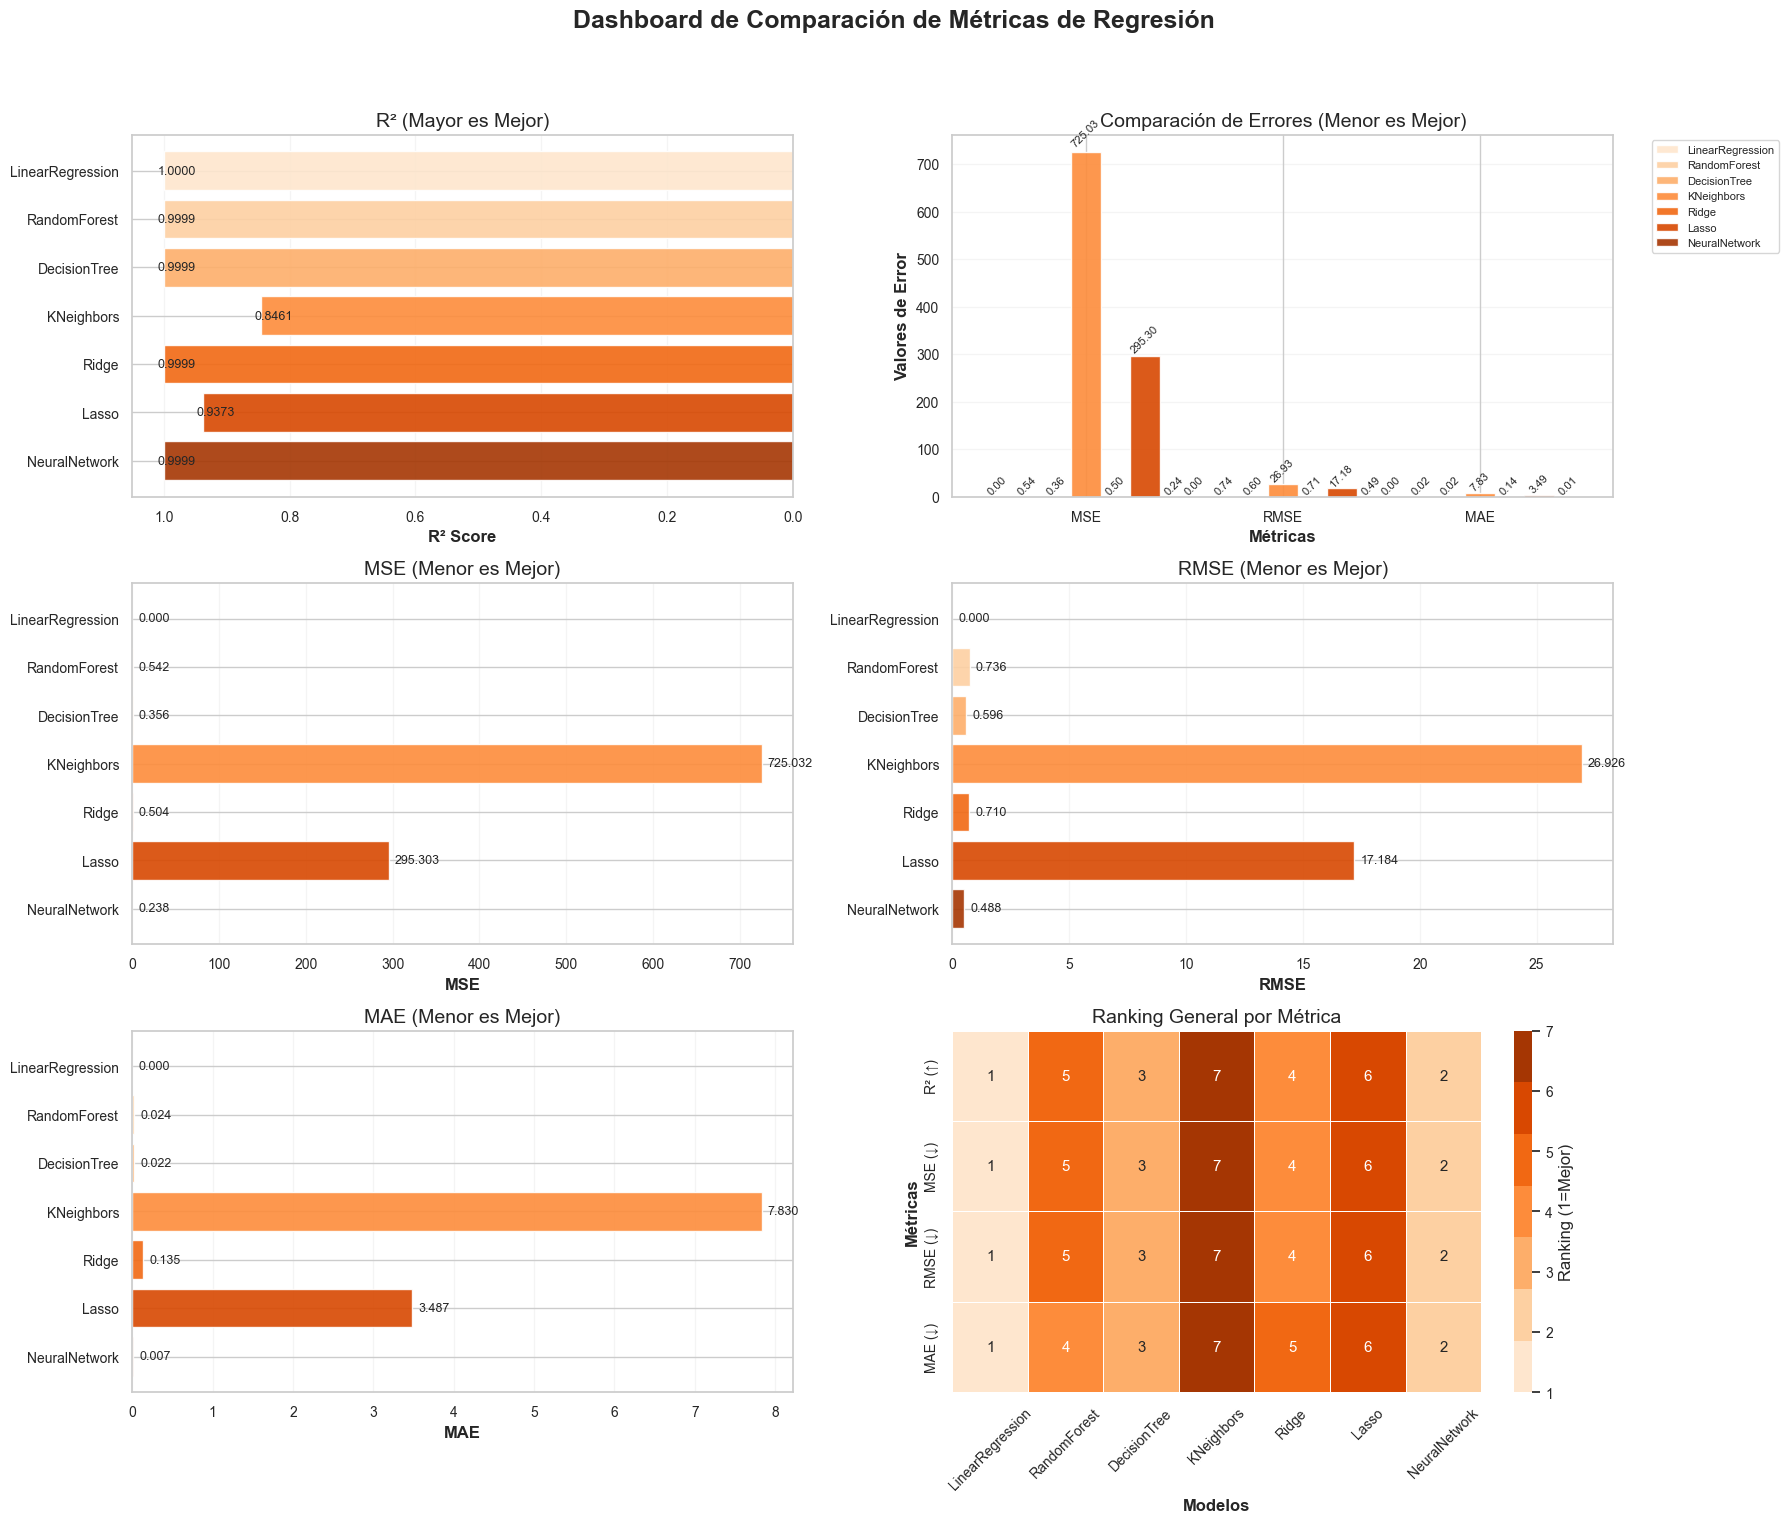

In [106]:
# --- Configuración del Dashboard ---
fig, axes = plt.subplots(3, 2, figsize=(18, 16)) # Mantenemos grid 3x2
fig.suptitle('Dashboard de Comparación de Métricas de Regresión', fontsize=18, fontweight='bold')

# Preparar datos comunes
models_names = list(test_metrics_results.keys())
colors = sns.color_palette("Oranges", len(models_names))  # Usar colores diferentes para trip

# --- Gráfico 1 (NUEVO): R² Score (Independiente) ---
ax1 = axes[0, 0] # Posición superior izquierda
r2_scores = [test_metrics_results[name]['R²'] for name in models_names]
bars1 = ax1.barh(models_names, r2_scores, color=colors, alpha=0.9)
ax1.set_xlabel('R² Score', fontweight='bold')
ax1.set_title('R² (Mayor es Mejor)')
ax1.grid(True, alpha=0.2, axis='x')
# Etiquetas en barras horizontales
for bar, score in zip(bars1, r2_scores):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.4f}',
             ha='left', va='center', fontsize=9)
ax1.invert_xaxis() # Opcional: para que la mejor barra (más larga) esté arriba si se ordena
ax1.invert_yaxis() # Para que los nombres de modelo coincidan con otras barras H

# --- Gráfico 2 (NUEVO): Comparación General (MSE, RMSE, MAE) ---
ax2 = axes[0, 1] # Posición superior derecha
metrics_compare = ['MSE', 'RMSE', 'MAE'] # Excluimos R²
x_pos = np.arange(len(metrics_compare))
width = 0.15 # Ajusta el ancho si es necesario

for i, (name, color) in enumerate(zip(models_names, colors)):
    # Obtener solo MSE, RMSE, MAE
    values = [test_metrics_results[name][metric] for metric in metrics_compare]
    bars2 = ax2.bar(x_pos + i * width, values, width, label=name, color=color, alpha=0.9, edgecolor='white')

    # Etiquetas en barras verticales (ajustadas)
    for bar, val in zip(bars2, values):
        height = bar.get_height()
        # Ajustar posición vertical para evitar solapamientos
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.01, f'{val:.2f}', # Usar .2f para errores
                 ha='center', va='bottom', fontsize=8, rotation=45)

ax2.set_xlabel('Métricas', fontweight='bold')
ax2.set_ylabel('Valores de Error', fontweight='bold')
ax2.set_title('Comparación de Errores (Menor es Mejor)')
ax2.set_xticks(x_pos + width * (len(models_names) - 1) / 2)
ax2.set_xticklabels(metrics_compare, rotation=0)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.2, axis='y')

# --- Gráfico 3: MSE (Individual) ---
ax3 = axes[1, 0] # Posición media izquierda
mse_scores = [test_metrics_results[name]['MSE'] for name in models_names]
bars3 = ax3.barh(models_names, mse_scores, color=colors, alpha=0.9)
ax3.set_xlabel('MSE', fontweight='bold')
ax3.set_title('MSE (Menor es Mejor)')
ax3.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars3, mse_scores):
    ax3.text(bar.get_width() + max(mse_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', # Ajuste decimales
             ha='left', va='center', fontsize=9)
ax3.invert_yaxis() # Para alinear nombres

# --- Gráfico 4: RMSE (Individual) ---
ax4 = axes[1, 1] # Posición media derecha
rmse_scores = [test_metrics_results[name]['RMSE'] for name in models_names]
bars4 = ax4.barh(models_names, rmse_scores, color=colors, alpha=0.9)
ax4.set_xlabel('RMSE', fontweight='bold')
ax4.set_title('RMSE (Menor es Mejor)')
ax4.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars4, rmse_scores):
    ax4.text(bar.get_width() + max(rmse_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             ha='left', va='center', fontsize=9)
ax4.invert_yaxis() # Para alinear nombres

# --- Gráfico 5: MAE (Individual) ---
ax5 = axes[2, 0] # Posición inferior izquierda
mae_scores = [test_metrics_results[name]['MAE'] for name in models_names]
bars5 = ax5.barh(models_names, mae_scores, color=colors, alpha=0.9)
ax5.set_xlabel('MAE', fontweight='bold')
ax5.set_title('MAE (Menor es Mejor)')
ax5.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars5, mae_scores):
    ax5.text(bar.get_width() + max(mae_scores)*0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             ha='left', va='center', fontsize=9)
ax5.invert_yaxis() # Para alinear nombres

# --- Gráfico 6: Ranking Heatmap (Independiente) ---
ax6 = axes[2, 1] # Posición inferior derecha
comparison_df = pd.DataFrame(test_metrics_results).T
# Usar todas las métricas originales para el ranking
metrics_all = ['R²', 'MSE', 'RMSE', 'MAE']
ranking_matrix = []
for metric in metrics_all:
    # Rankear R² descendente, errores ascendente
    ranked = comparison_df[metric].rank(ascending=(metric != 'R²'))
    ranking_matrix.append(ranked.values)

# Crear DataFrame del ranking
ranking_df = pd.DataFrame(ranking_matrix,
                          index=[f'{m} {"(↑)" if m=="R²" else "(↓)"}' for m in metrics_all],
                          columns=models_names)

sns.heatmap(ranking_df, annot=True, fmt='.0f', cmap=colors, ax=ax6, # Usar Blues_r para que 1 sea oscuro
            cbar_kws={'label': 'Ranking (1=Mejor)'}, linewidths=.5)
ax6.set_title('Ranking General por Métrica')
ax6.set_xlabel('Modelos', fontweight='bold')
ax6.set_ylabel('Métricas', fontweight='bold')
# Rotar etiquetas X para evitar solapamiento
ax6.tick_params(axis='x', rotation=45)

# --- Ajuste Final ---
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar rect para dejar espacio al supertítulo
plt.show()

## 4.21 Análisis de Campeones para Predicción de Duración

### Identificación de Mejores Modelos Temporales

Esta celda replica el análisis de campeones aplicado al dominio temporal:

### Análisis de Campeones Temporales:
**Mejor MAE Temporal**: Modelo con menor error absoluto en minutos
**Mejor MSE Temporal**: Modelo con menor error cuadrático en predicción temporal
**Mejor RMSE Temporal**: Modelo con menor error estándar temporal
**Mejor R² Temporal**: Modelo con mayor capacidad explicativa de varianza temporal

### Ranking Promedio Temporal:
**Metodología**: Promedio de rankings individuales para métricas temporales
**Interpretación**: Modelo más consistente para predicción de duración
**Comparación**: Permite contrastar con ranking de total_amount

### Insights del Enfoque Dual:
Comparando campeones de ambos dominios:
- **Algoritmos Versátiles**: Buenos en ambos targets (tiempo y dinero)
- **Algoritmos Especializados**: Mejor performance en un dominio específico
- **Complejidad Relativa**: Identificar cuál predicción es más challenging
- **Selección Estratégica**: Decidir si usar modelos específicos o un modelo generalista

In [107]:
# Resumen Mejorado con Ranking Promedio
print("\nResumen de los Mejores Modelos")
best_models = {}
metrics_reg = ['MAE', 'MSE', 'RMSE', 'R²']
for metric in metrics_reg:
    if metric == 'R²':
        best = max(test_metrics_results.items(), key=lambda x: x[1][metric])
    else:
        best = min(test_metrics_results.items(), key=lambda x: x[1][metric])
    print(f"Mejor {metric:>4} {'(Mayor)':<7}: {best[0]:<20} = {best[1][metric]:.4f}")
    best_models[metric] = best[0]

# Ranking Promedio
avg_ranks = ranking_df.mean().sort_values()
print("\nRanking Promedio (Menor = Mejor General):")
for model, rank in avg_ranks.items():
    print(f"{model:<20}: {rank:.2f}")


Resumen de los Mejores Modelos
Mejor  MAE (Mayor): LinearRegression     = 0.0000
Mejor  MSE (Mayor): LinearRegression     = 0.0000
Mejor RMSE (Mayor): LinearRegression     = 0.0000
Mejor   R² (Mayor): LinearRegression     = 1.0000

Ranking Promedio (Menor = Mejor General):
LinearRegression    : 1.00
NeuralNetwork       : 2.00
DecisionTree        : 3.00
Ridge               : 4.25
RandomForest        : 4.75
Lasso               : 6.00
KNeighbors          : 7.00


## 4.22 Persistencia de Datos de Modelado (Trip Duration)

### Exportación del Dataset de Duración

Esta celda final guarda el dataset de modelado temporal para completar la trazabilidad:

### Características del Archivo de Duración:
**Nombre**: `modeling_trip_green_tripdata_2025-06.parquet`
**Contenido**: Dataset completo usado para modelado de `trip_duration_min`
**Propósito**: Reproducibilidad y auditoría del proceso temporal
**Complemento**: Junto con el archivo de total_amount, completa la documentación

### Completitud del Enfoque Dual:
Con ambos archivos persistidos:
- **Trazabilidad Completa**: Registro de datos usados en ambos ciclos
- **Reproducibilidad**: Capacidad de recrear exactamente ambos análisis
- **Auditoría**: Verificación independiente de metodología y resultados
- **Colaboración**: Datasets disponibles para análisis adicionales
- **Versionado**: Control de versiones de datos de modelado

### Beneficios de la Persistencia Dual:
- **Comparación**: Facilita análisis comparativo entre dominios
- **Eficiencia**: Evita recomputar preprocessing para futuros estudios
- **Documentación**: Evidencia completa del proceso de modelado dual
- **Extensibilidad**: Base para modelos ensemble o híbridos futuros

In [108]:
# Define el nombre del archivo
modeling = 'modeling_trip_green_tripdata_2025-06.parquet'

# Guarda el DataFrame df_modeling en formato Parquet
try:
    df_modeling_trip.to_parquet(modeling, index=False) 
    print(f"DataFrame guardado exitosamente como '{modeling}'")
except Exception as e:
    print(f"Error al guardar como Parquet: {e}")

DataFrame guardado exitosamente como 'modeling_trip_green_tripdata_2025-06.parquet'
